<a href="https://colab.research.google.com/github/martiemmanuelp/data-analyst-jobs-market-analysis/blob/main/notebooks/data_analyst_jobs_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import sqlite3
import re
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/martiemmanuelp/data-analyst-jobs-market-analysis/main/DataAnalyst.csv"
df = pd.read_csv(url)

# Clean salary column — extract min, max, and average
def extract_salary(salary_str):
    numbers = re.findall(r'\d+', salary_str)
    if len(numbers) >= 2:
        min_sal = int(numbers[0]) * 1000
        max_sal = int(numbers[1]) * 1000
        avg_sal = (min_sal + max_sal) / 2
        return min_sal, max_sal, avg_sal
    return None, None, None

df[['Salary_Min', 'Salary_Max', 'Salary_Avg']] = df['Salary Estimate'].apply(
    lambda x: pd.Series(extract_salary(x))
)

# Clean location - only take first two parts
location_split = df['Location'].str.split(',', expand=True)
df['City'] = location_split[0]
df['State'] = location_split[1].str.strip() if 1 in location_split.columns else None

# Clean company name
df['Company Name'] = df['Company Name'].str.split('\n').str[0]

# Drop rows with missing salary
df = df.dropna(subset=['Salary_Avg'])

print(df.shape)
print(df[['Job Title', 'Salary_Min', 'Salary_Max', 'Salary_Avg', 'City', 'State']].head())

(2252, 21)
                                           Job Title  Salary_Min  Salary_Max  \
0  Data Analyst, Center on Immigration and Justic...     37000.0     66000.0   
1                               Quality Data Analyst     37000.0     66000.0   
2  Senior Data Analyst, Insights & Analytics Team...     37000.0     66000.0   
3                                       Data Analyst     37000.0     66000.0   
4                             Reporting Data Analyst     37000.0     66000.0   

   Salary_Avg      City State  
0     51500.0  New York    NY  
1     51500.0  New York    NY  
2     51500.0  New York    NY  
3     51500.0  New York    NY  
4     51500.0  New York    NY  


In [ ]:
# Load into SQLite
conn = sqlite3.connect('jobs.db')

df.to_sql('jobs', conn, if_exists='replace', index=False)

print("Database created successfully")

# Verify
verify = pd.read_sql_query("SELECT COUNT(*) as total_jobs FROM jobs", conn)
print(verify)

Database created successfully
   total_jobs
0        2252


In [ ]:
query1 = """
SELECT "Job Title",
       ROUND(AVG(Salary_Avg), 0) as Avg_Salary,
       COUNT(*) as Job_Count
FROM jobs
WHERE Salary_Avg IS NOT NULL
GROUP BY "Job Title"
HAVING Job_Count >= 10
ORDER BY Avg_Salary DESC
LIMIT 10
"""
df_titles = pd.read_sql_query(query1, conn)
print(df_titles)

                 Job Title  Avg_Salary  Job_Count
0        Lead Data Analyst     80800.0         15
1         Sr. Data Analyst     77357.0         21
2           Data Analyst I     75727.0         11
3    Business Data Analyst     75607.0         28
4             Data Analyst     72585.0        405
5      Senior Data Analyst     70139.0         90
6     Data Quality Analyst     68824.0         17
7  Data Governance Analyst     68719.0         16
8   Financial Data Analyst     68000.0         12
9         Data Analyst III     65500.0         11


In [ ]:
query2 = """
SELECT State,
       ROUND(AVG(Salary_Avg), 0) as Avg_Salary,
       COUNT(*) as Job_Count
FROM jobs
WHERE State IS NOT NULL
GROUP BY State
HAVING Job_Count >= 10
ORDER BY Avg_Salary DESC
LIMIT 10
"""
df_states = pd.read_sql_query(query2, conn)
print(df_states)

  State  Avg_Salary  Job_Count
0    CA     88432.0        626
1    IL     78311.0        164
2    CO     73619.0         88
3    NJ     73000.0         86
4    NY     71412.0        345
5    AZ     70789.0         97
6    NC     68111.0         90
7    VA     65188.0         48
8    WA     64755.0         53
9    PA     61728.0        114


In [ ]:
query3 = """
SELECT Industry,
       ROUND(AVG(Salary_Avg), 0) as Avg_Salary,
       COUNT(*) as Job_Count
FROM jobs
WHERE Industry != '-1'
GROUP BY Industry
HAVING Job_Count >= 10
ORDER BY Avg_Salary DESC
LIMIT 10
"""
df_industry = pd.read_sql_query(query3, conn)
print(df_industry)

                                  Industry  Avg_Salary  Job_Count
0                Biotech & Pharmaceuticals     83106.0         33
1                              Real Estate     80917.0         12
2                                 Internet     79662.0         65
3             Computer Hardware & Software     77649.0        111
4  Enterprise Software & Network Solutions     77326.0         69
5                               Accounting     76295.0         39
6                   Staffing & Outsourcing     73238.0        322
7         Health Care Services & Hospitals     72808.0        151
8                  Advertising & Marketing     72598.0         51
9     Architectural & Engineering Services     72308.0         13


In [ ]:
query4 = """
SELECT City,
       State,
       COUNT(*) as Job_Count,
       ROUND(AVG(Salary_Avg), 0) as Avg_Salary
FROM jobs
GROUP BY City, State
ORDER BY Job_Count DESC
LIMIT 10
"""
df_cities = pd.read_sql_query(query4, conn)
print(df_cities)

            City State  Job_Count  Avg_Salary
0       New York    NY        310     71235.0
1        Chicago    IL        130     78727.0
2  San Francisco    CA        119     99273.0
3         Austin    TX         81     58704.0
4    Los Angeles    CA         80     67631.0
5      Charlotte    NC         78     68173.0
6        Houston    TX         72     62181.0
7         Dallas    TX         66     50576.0
8      San Diego    CA         62     91460.0
9   Philadelphia    PA         56     62411.0


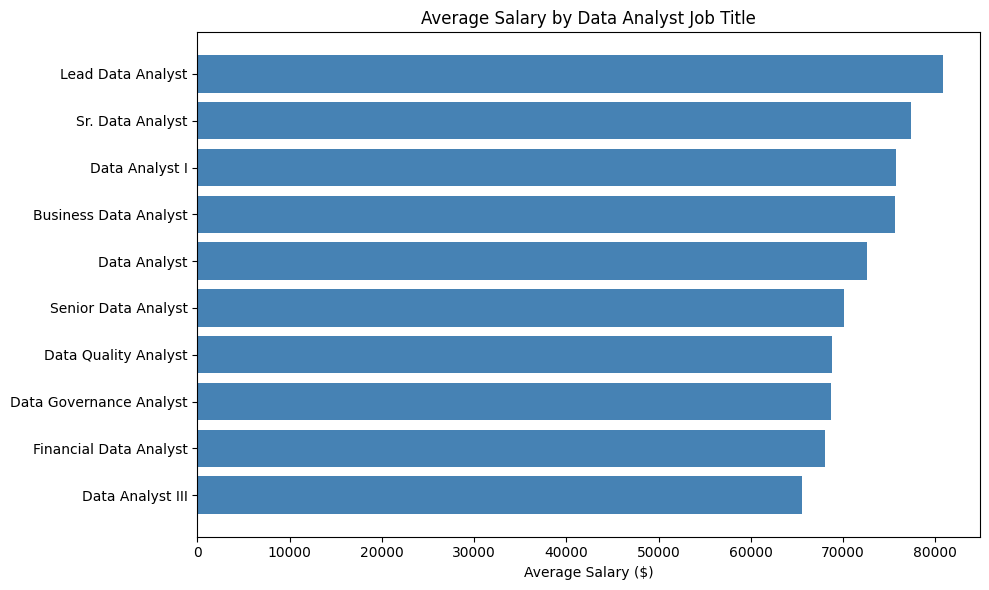

In [ ]:
df_titles_sorted = df_titles.sort_values('Avg_Salary')

plt.figure(figsize=(10,6))
plt.barh(df_titles_sorted['Job Title'], df_titles_sorted['Avg_Salary'], color='steelblue')
plt.title('Average Salary by Data Analyst Job Title')
plt.xlabel('Average Salary ($)')
plt.tight_layout()
plt.savefig('salary_by_title.png', dpi=150, bbox_inches='tight')
plt.show()

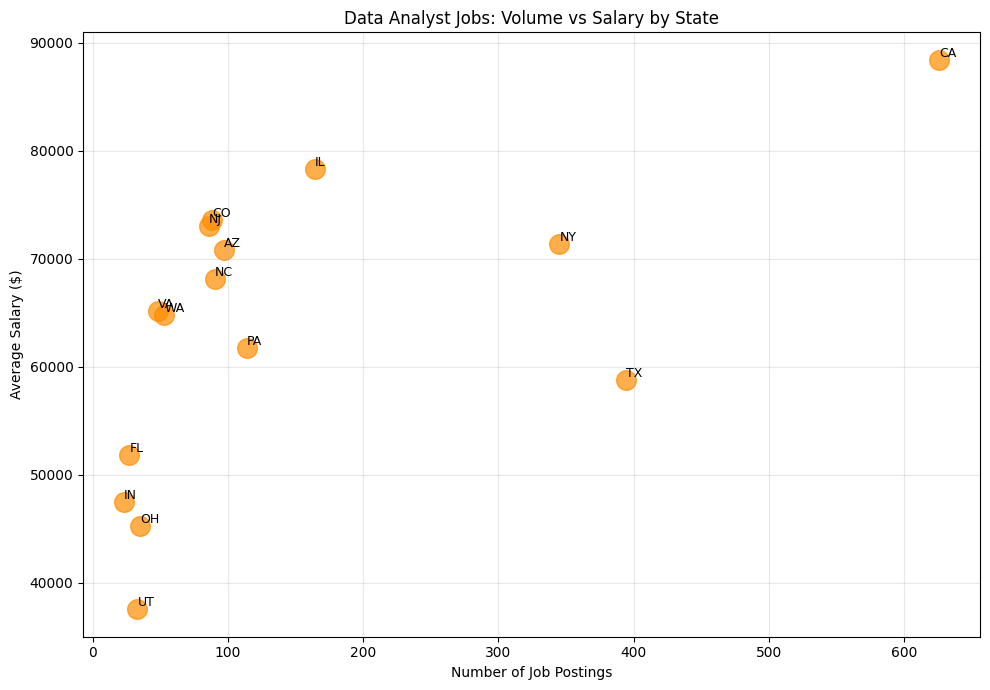

In [ ]:
df_state_scatter = pd.read_sql_query("""
    SELECT State, ROUND(AVG(Salary_Avg),0) as Avg_Salary, COUNT(*) as Job_Count
    FROM jobs
    WHERE State IS NOT NULL
    GROUP BY State
    HAVING Job_Count >= 10
    ORDER BY Job_Count DESC
    LIMIT 15
""", conn)

plt.figure(figsize=(10,7))
plt.scatter(df_state_scatter['Job_Count'], df_state_scatter['Avg_Salary'],
            s=200, color='darkorange', alpha=0.7)

for _, row in df_state_scatter.iterrows():
    plt.annotate(row['State'], (row['Job_Count'], row['Avg_Salary']),
                fontsize=9, ha='left', va='bottom')

plt.title('Data Analyst Jobs: Volume vs Salary by State')
plt.xlabel('Number of Job Postings')
plt.ylabel('Average Salary ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('state_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

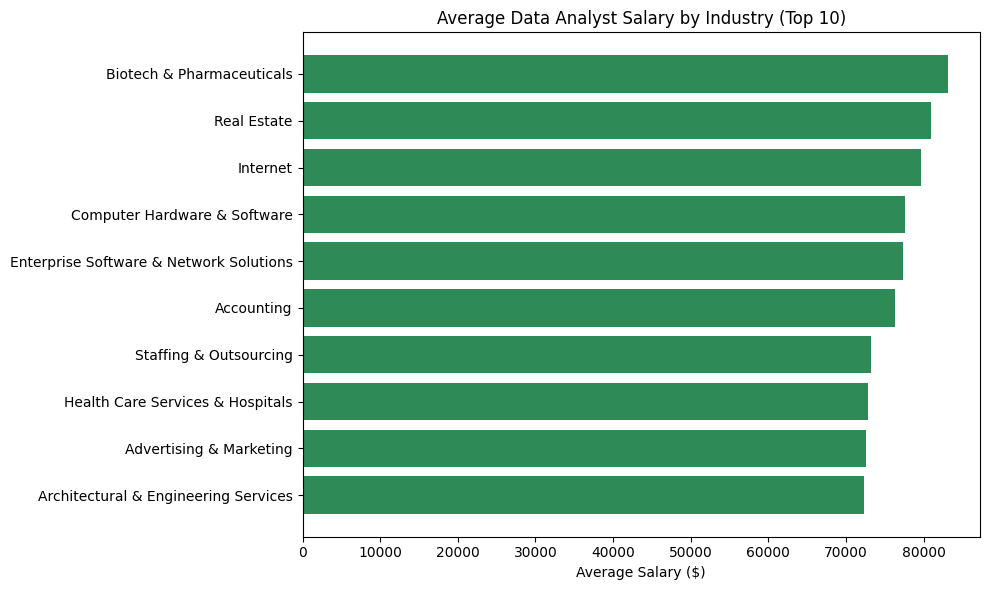

In [ ]:
df_industry_sorted = df_industry.sort_values('Avg_Salary')

plt.figure(figsize=(10,6))
plt.barh(df_industry_sorted['Industry'], df_industry_sorted['Avg_Salary'], color='seagreen')
plt.title('Average Data Analyst Salary by Industry (Top 10)')
plt.xlabel('Average Salary ($)')
plt.tight_layout()
plt.savefig('salary_by_industry.png', dpi=150, bbox_inches='tight')
plt.show()

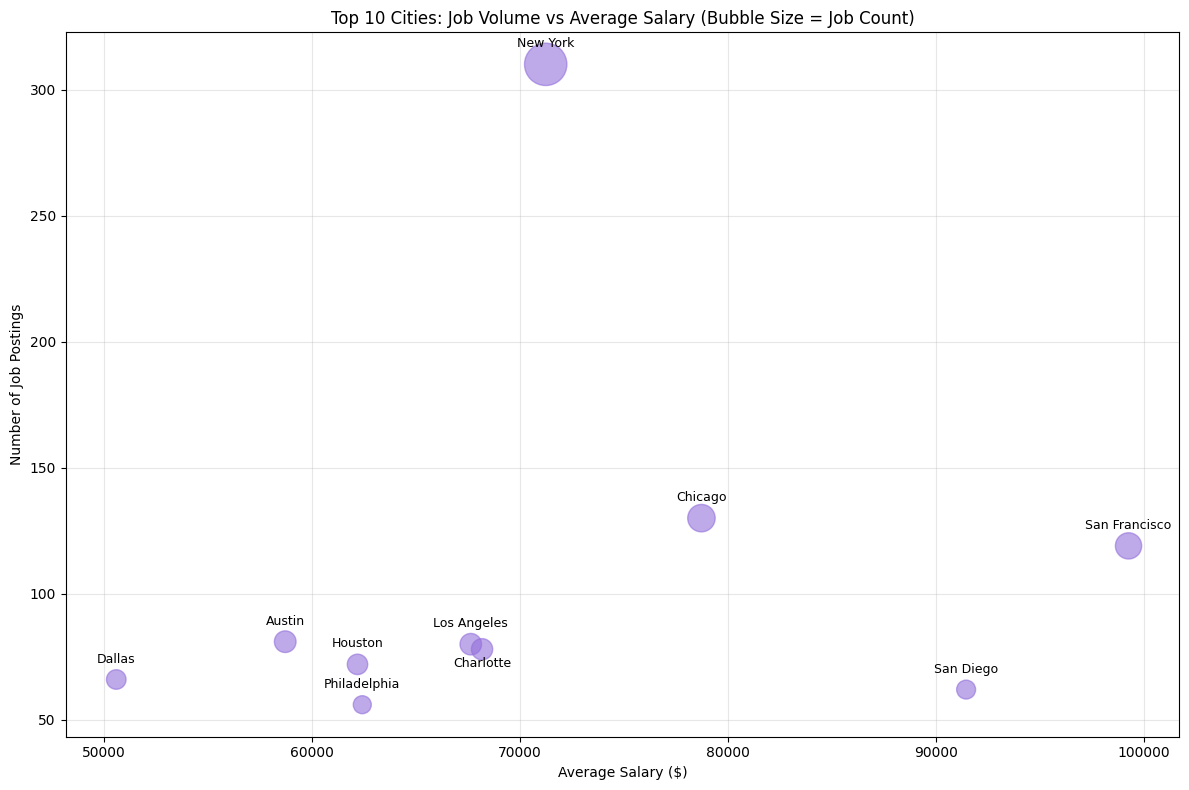

In [ ]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    df_cities['Avg_Salary'],
    df_cities['Job_Count'],
    s=df_cities['Job_Count'] * 3,
    alpha=0.6,
    color='mediumpurple'
)

for _, row in df_cities.iterrows():
    offset = (0, 10)
    if row['City'] == 'Charlotte':
        offset = (0, -15)
    elif row['City'] == 'Los Angeles':
        offset = (0, 10)
    plt.annotate(row['City'],
                (row['Avg_Salary'], row['Job_Count']),
                fontsize=9, ha='center', va='bottom',
                xytext=offset, textcoords='offset points')

plt.title('Top 10 Cities: Job Volume vs Average Salary (Bubble Size = Job Count)')
plt.xlabel('Average Salary ($)')
plt.ylabel('Number of Job Postings')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('city_bubble.png', dpi=150, bbox_inches='tight')
plt.show()